# 1. import module and reading data

In [75]:
class Vocabulary:
    PAD, START, END, UNK = "<pad>", "<start>", "<end>", "<unk>"
    SPECIAL_TOKENS = [PAD, START, END, UNK]

    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        for tok in self.SPECIAL_TOKENS:
            self._add(tok)

    def _add(self, word):
        if word not in self.word2idx:
            i = len(self.word2idx)
            self.word2idx[word] = i
            self.idx2word[i] = word

    @classmethod
    def build(cls, tokenized_captions, min_freq=5):
        counter = Counter()
        for tokens in tokenized_captions:
            counter.update(tokens)
        vocab = cls()
        for word, count in counter.items():
            if count >= min_freq:
                vocab._add(word)
        vocab.freq = counter
        return vocab

    @property
    def pad_idx(self):   return self.word2idx[self.PAD]
    @property
    def start_idx(self): return self.word2idx[self.START]
    @property
    def end_idx(self):   return self.word2idx[self.END]
    @property
    def unk_idx(self):   return self.word2idx[self.UNK]

    def encode(self, tokens, add_special=True):
        ids = [self.word2idx.get(t, self.unk_idx) for t in tokens]
        if add_special:
            ids = [self.start_idx] + ids + [self.end_idx]
        return ids

    def decode(self, ids, strip_special=True):
        words = []
        for i in ids:
            w = self.idx2word.get(int(i), self.UNK)
            if strip_special:
                if w == self.END: break
                if w in (self.PAD, self.START): continue
            words.append(w)
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)


In [76]:
import os
import pickle
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# Project paths
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
IMAGE_DIR = DATA_DIR / "images" / "val"
PROCESSED_DIR = DATA_DIR / "processed"

# Load processed Phase 1 outputs
with open(PROCESSED_DIR / "vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

with open(PROCESSED_DIR / "train_data.pkl", "rb") as f:
    train_data = pickle.load(f)

with open(PROCESSED_DIR / "val_data.pkl", "rb") as f:
    val_data = pickle.load(f)

with open(PROCESSED_DIR / "test_data.pkl", "rb") as f:
    test_data = pickle.load(f)

with open(PROCESSED_DIR / "config.pkl", "rb") as f:
    config = pickle.load(f)

print("Project root:", PROJECT_ROOT)
print("Image directory:", IMAGE_DIR)
print("Processed directory:", PROCESSED_DIR)

print("Vocab size:", len(vocab))
print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_data))
print("Config:", config)

Project root: C:\Users\vley1\DL_Assignment_3_Group31
Image directory: C:\Users\vley1\DL_Assignment_3_Group31\data\images\val
Processed directory: C:\Users\vley1\DL_Assignment_3_Group31\data\processed
Vocab size: 3214
Train size: 5279
Validation size: 1131
Test size: 1132
Config: {'random_seed': 42, 'min_word_freq': 5, 'max_caption_length': 25, 'min_caption_length': 3, 'train_ratio': 0.7, 'val_ratio': 0.15, 'test_ratio': 0.15, 'filter_rejected': True, 'filter_precanned': True, 'vocab_size': 3214, 'imagenet_mean': [0.485, 0.456, 0.406], 'imagenet_std': [0.229, 0.224, 0.225]}


In [77]:
print("Type of train_data:", type(train_data))
print("Type of first item:", type(train_data[0]))
print("First item:")
print(train_data[0])

Type of train_data: <class 'list'>
Type of first item: <class 'dict'>
First item:
{'image_id': 23906, 'file_name': 'VizWiz_val_00000475.jpg', 'image_path': 'C:\\Users\\vley1\\DL_Assignment_3_Group31\\data\\images\\val\\VizWiz_val_00000475.jpg', 'captions_raw': ['A Dell brand black computer monitor with white windows on the screen.', 'A Dell computer screen with a screen shot that has a list of dates at the bottom.', 'The screen is displaying multiple dates on the screen of a computer.', 'The display of a Dell computer shows a screen malfunction.', 'An internet window turned sideways on a Dell monitor'], 'captions_tokens': [['a', 'dell', 'brand', 'black', 'computer', 'monitor', 'with', 'white', 'windows', 'on', 'the', 'screen'], ['a', 'dell', 'computer', 'screen', 'with', 'a', 'screen', 'shot', 'that', 'has', 'a', 'list', 'of', 'dates', 'at', 'the', 'bottom'], ['the', 'screen', 'is', 'displaying', 'multiple', 'dates', 'on', 'the', 'screen', 'of', 'a', 'computer'], ['the', 'display', 'of

In [78]:
print(train_data[0].keys())

for key, value in train_data[0].items():
    print(key, ":", value)

dict_keys(['image_id', 'file_name', 'image_path', 'captions_raw', 'captions_tokens'])
image_id : 23906
file_name : VizWiz_val_00000475.jpg
image_path : C:\Users\vley1\DL_Assignment_3_Group31\data\images\val\VizWiz_val_00000475.jpg
captions_raw : ['A Dell brand black computer monitor with white windows on the screen.', 'A Dell computer screen with a screen shot that has a list of dates at the bottom.', 'The screen is displaying multiple dates on the screen of a computer.', 'The display of a Dell computer shows a screen malfunction.', 'An internet window turned sideways on a Dell monitor']
captions_tokens : [['a', 'dell', 'brand', 'black', 'computer', 'monitor', 'with', 'white', 'windows', 'on', 'the', 'screen'], ['a', 'dell', 'computer', 'screen', 'with', 'a', 'screen', 'shot', 'that', 'has', 'a', 'list', 'of', 'dates', 'at', 'the', 'bottom'], ['the', 'screen', 'is', 'displaying', 'multiple', 'dates', 'on', 'the', 'screen', 'of', 'a', 'computer'], ['the', 'display', 'of', 'a', 'dell', '

# 2. Dataset and Dataloading

Each image in the VizWiz-Captions dataset has five reference captions.  
For training, one caption is selected from the available references and converted into token IDs using the vocabulary built in Phase 1.

The image is loaded from the saved image path, resized to 224×224, converted into a tensor, and normalised using ImageNet statistics because the encoder uses a pretrained CNN.

In [79]:
import random
from torch.nn.utils.rnn import pad_sequence

class VizWizCaptionDataset(Dataset):
    def __init__(self, data, vocab, transform=None, train=True):
        self.data = data
        self.vocab = vocab
        self.transform = transform
        self.train = train

    def __len__(self):
        return len(self.data)

    def encode_caption(self, tokens):
        ids = self.vocab.encode(tokens)
        return torch.tensor(ids, dtype=torch.long)

    def __getitem__(self, idx):
        item = self.data[idx]

        image = Image.open(item["image_path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.train:
            tokens = random.choice(item["captions_tokens"])
        else:
            tokens = item["captions_tokens"][0]

        caption = self.encode_caption(tokens)

        return image, caption, item["captions_tokens"], item["file_name"]

In [80]:
def collate_fn(batch):
    images, captions, references, file_names = zip(*batch)

    images = torch.stack(images, dim=0)

    captions = pad_sequence(
        captions,
        batch_first=True,
        padding_value=vocab.pad_idx
    )

    return images, captions, references, file_names

In [81]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=config["imagenet_mean"],
        std=config["imagenet_std"]
    )
])

train_dataset = VizWizCaptionDataset(
    train_data,
    vocab,
    transform=transform,
    train=True
)

val_dataset = VizWizCaptionDataset(
    val_data,
    vocab,
    transform=transform,
    train=False
)

test_dataset = VizWizCaptionDataset(
    test_data,
    vocab,
    transform=transform,
    train=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 165
Validation batches: 36
Test batches: 36


In [82]:
images, captions, references, file_names = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Caption batch shape:", captions.shape)
print("First file name:", file_names[0])
print("First caption ids:", captions[0])
print("Decoded first caption:")
print(vocab.decode(captions[0].tolist()))
print("Reference captions:")
print(references[0])

Image batch shape: torch.Size([32, 3, 224, 224])
Caption batch shape: torch.Size([32, 27])
First file name: VizWiz_val_00001761.jpg
First caption ids: tensor([   1,    4,  272,   20,  279,   24,   13,    4,  280,  117,  150,   20,
           4, 1246,    2,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0])
Decoded first caption:
a can of food is on a counter in front of a microwave
Reference captions:
[['the', 'buttons', 'on', 'a', 'white', 'microwave', 'with', 'something', 'silver', 'in', 'front', 'of', 'the', 'door'], ['the', 'buttons', 'and', 'lcd', 'display', 'on', 'the', 'front', 'of', 'a', 'microwave'], ['a', 'microwave', 'control', 'panel', 'the', 'numbers', 'one', 'and', '5', 'are', 'highlighted', 'in', 'yellow'], ['a', 'can', 'of', 'food', 'is', 'on', 'a', 'counter', 'in', 'front', 'of', 'a', 'microwave'], ['a', 'white', 'microwave', 'control', 'panel', 'is', 'shown', 'with', 'the', 'top', 'of', 'a', 'pop', 'top', 'can', 'of', 'soup', 'at', 'the',

# 3. Phase 2 Model 1 set up : DenseNet121 + LSTM baseline



The baseline model uses a pretrained DenseNet121 encoder and a single-layer LSTM decoder.

DenseNet121 extracts visual features from the image, while the LSTM generates captions word by word based on the extracted feature representation.

In [83]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


### 3.1 DenseNet121 Image Encoder

The encoder uses a pretrained DenseNet121 model to extract image features.  
The original classifier layer is removed, and the extracted CNN feature vector is projected into the same dimension as the word embedding size so that it can be used by the LSTM decoder.

In [84]:
class DenseNetEncoder(nn.Module):
    def __init__(self, embed_size):
        super(DenseNetEncoder, self).__init__()

        # Load pretrained DenseNet121
        densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

        # Use DenseNet feature extractor only, remove classifier
        self.features = densenet.features

        # DenseNet121 output channel size is 1024
        self.fc = nn.Linear(1024, embed_size)

        # Activation and dropout
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

        # Freeze CNN feature extractor for baseline model
        for param in self.features.parameters():
            param.requires_grad = False

    def forward(self, images):
        features = self.features(images)

        # Global average pooling
        features = nn.functional.adaptive_avg_pool2d(features, (1, 1))

        # Flatten: [batch_size, 1024, 1, 1] -> [batch_size, 1024]
        features = features.view(features.size(0), -1)

        # Project to embedding size
        features = self.fc(features)
        features = self.relu(features)
        features = self.dropout(features)

        return features

Testing encoder

In [85]:
embed_size = 256

encoder = DenseNetEncoder(embed_size).to(device)

images, captions, references, file_names = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    image_features = encoder(images)

print("Input image shape:", images.shape)
print("Encoded feature shape:", image_features.shape)

Input image shape: torch.Size([32, 3, 224, 224])
Encoded feature shape: torch.Size([32, 256])


### 3.2 LSTM Caption Decoder

The decoder uses an embedding layer and an LSTM to generate captions.  
During training, the encoded image feature is treated as the first input to the LSTM, followed by the embedded caption tokens.

In [86]:
class LSTMDecoder(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(LSTMDecoder, self).__init__()

        self.embed = nn.Embedding(vocab_size, embed_size, padding_idx=vocab.pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.3)

    def forward(self, image_features, captions):
        # captions[:, :-1] removes the final token because the model predicts the next token
        captions_input = captions[:, :-1]

        embeddings = self.embed(captions_input)
        embeddings = self.dropout(embeddings)

        # Add image feature as the first time step
        image_features = image_features.unsqueeze(1)

        lstm_input = torch.cat((image_features, embeddings), dim=1)

        outputs, _ = self.lstm(lstm_input)

        predictions = self.fc(outputs)

        return predictions

Testing decoder

In [87]:
embed_size = 256
hidden_size = 512
vocab_size = len(vocab)

decoder = LSTMDecoder(
    embed_size=embed_size,
    hidden_size=hidden_size,
    vocab_size=vocab_size
).to(device)

images, captions, references, file_names = next(iter(train_loader))
images = images.to(device)
captions = captions.to(device)

with torch.no_grad():
    image_features = encoder(images)
    outputs = decoder(image_features, captions)

print("Image feature shape:", image_features.shape)
print("Caption input shape:", captions.shape)
print("Decoder output shape:", outputs.shape)

Image feature shape: torch.Size([32, 256])
Caption input shape: torch.Size([32, 27])
Decoder output shape: torch.Size([32, 27, 3214])


### 3.3 Full Image Captioning Model

The full baseline model combines the DenseNet121 encoder and the LSTM decoder.  
The encoder converts each image into a visual feature vector, and the decoder uses this feature to generate a caption sequence.

In [88]:
class DenseNetLSTMCaptioningModel(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(DenseNetLSTMCaptioningModel, self).__init__()

        self.encoder = DenseNetEncoder(embed_size)
        self.decoder = LSTMDecoder(
            embed_size=embed_size,
            hidden_size=hidden_size,
            vocab_size=vocab_size,
            num_layers=num_layers
        )

    def forward(self, images, captions):
        image_features = self.encoder(images)
        outputs = self.decoder(image_features, captions)
        return outputs

Initialize the model

In [89]:
embed_size = 256
hidden_size = 512
vocab_size = len(vocab)
num_layers = 1

model1 = DenseNetLSTMCaptioningModel(
    embed_size=embed_size,
    hidden_size=hidden_size,
    vocab_size=vocab_size,
    num_layers=num_layers
).to(device)

print(model1)

DenseNetLSTMCaptioningModel(
  (encoder): DenseNetEncoder(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(

Testing on forward pass

In [90]:
images, captions, references, file_names = next(iter(train_loader))

images = images.to(device)
captions = captions.to(device)

with torch.no_grad():
    outputs = model1(images, captions)

print("Images shape:", images.shape)
print("Captions shape:", captions.shape)
print("Model output shape:", outputs.shape)
print("Expected vocab size:", vocab_size)

Images shape: torch.Size([32, 3, 224, 224])
Captions shape: torch.Size([32, 27])
Model output shape: torch.Size([32, 27, 3214])
Expected vocab size: 3214


### 3.4 Model 1 Training

The model is trained using CrossEntropyLoss.  
The padding token is ignored during loss calculation so that padded positions do not affect optimisation.

During training, the model predicts the next word at each time step.

setting up loss and optimizer

In [91]:
criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)

optimizer = torch.optim.Adam(
    model1.parameters(),
    lr=1e-3
)

num_epochs = 5

Training function

In [92]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for images, captions, references, file_names in tqdm(dataloader):
        images = images.to(device)
        captions = captions.to(device)

        outputs = model(images, captions)

        targets = captions

        loss = criterion(
            outputs.reshape(-1, outputs.size(-1)),
            targets.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    return avg_loss

Validation function

In [93]:
def evaluate_loss(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, captions, references, file_names in tqdm(dataloader):
            images = images.to(device)
            captions = captions.to(device)

            outputs = model(images, captions)
            targets = captions

            loss = criterion(
                outputs.reshape(-1, outputs.size(-1)),
                targets.reshape(-1)
            )

            total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    return avg_loss

Training

In [94]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")

    train_loss = train_one_epoch(
        model1,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = evaluate_loss(
        model1,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

Epoch 1/5


100%|██████████| 36/36 [00:39<00:00,  1.11s/it]


Train Loss: 4.6373
Val Loss: 4.0101
Epoch 2/5


100%|██████████| 36/36 [00:38<00:00,  1.07s/it]


Train Loss: 3.9437
Val Loss: 3.7561
Epoch 3/5


...

Train Loss: 3.7234
Val Loss: 3.5875
Epoch 4/5


100%|██████████| 36/36 [00:39<00:00,  1.09s/it]


Train Loss: 3.5625
Val Loss: 3.4696
Epoch 5/5


100%|██████████| 36/36 [00:39<00:00,  1.09s/it]

Train Loss: 3.4116
Val Loss: 3.3922


drawing loss

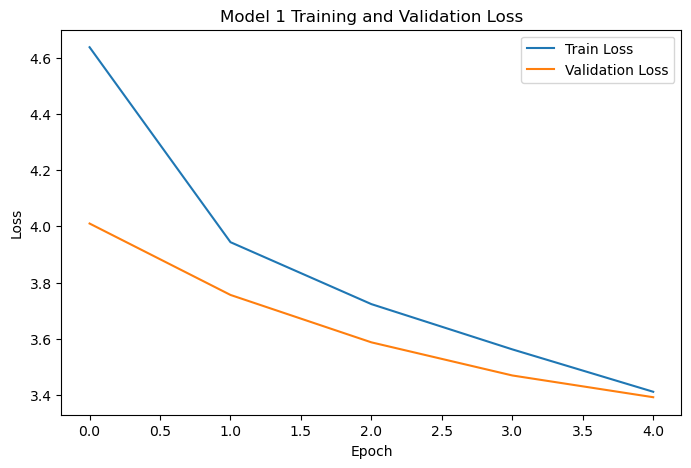

In [95]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 1 Training and Validation Loss")
plt.legend()
plt.show()

### 3.5 Model 1 Evaluation

This section evaluates the DenseNet121 + LSTM baseline model using automatic metrics and qualitative caption examples.

The model generates captions using greedy decoding.  
BLEU-1, BLEU-2, BLEU-3, and BLEU-4 are calculated by comparing generated captions with the five human-written reference captions for each image.

In [96]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vley1\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [97]:
def clean_decoded_tokens(tokens):
    special_tokens = {"<start>", "<end>", "<pad>", "<unk>"}
    return [token for token in tokens if token not in special_tokens]

In [98]:
def ids_to_tokens(ids, vocab):
    tokens = []
    for idx in ids:
        word = vocab.idx2word.get(int(idx), vocab.UNK)

        if word == vocab.END:
            break

        if word in [vocab.PAD, vocab.START, vocab.END, vocab.UNK]:
            continue

        tokens.append(word)

    return tokens

In [99]:
def generate_caption_model1(model, image, vocab, max_length=30):
    model.eval()

    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        image_features = model.encoder(image)

        inputs = image_features.unsqueeze(1)

        states = None
        generated_ids = []

        for _ in range(max_length):
            outputs, states = model.decoder.lstm(inputs, states)
            predictions = model.decoder.fc(outputs.squeeze(1))

            predicted_id = predictions.argmax(1).item()
            generated_ids.append(predicted_id)

            if predicted_id == vocab.end_idx:
                break

            inputs = model.decoder.embed(
                torch.tensor([predicted_id], device=device)
            ).unsqueeze(1)

    generated_tokens = ids_to_tokens(generated_ids, vocab)

    return generated_tokens

Testing on image

In [100]:
sample_image, sample_caption, sample_references, sample_file_name = test_dataset[0]

generated_tokens = generate_caption_model1(
    model1,
    sample_image,
    vocab,
    max_length=30
)

print("File name:", sample_file_name)
print("Generated caption:")
print(" ".join(generated_tokens))

print("\nReference captions:")
for ref in sample_references:
    print(" ".join(ref))

File name: VizWiz_val_00003472.jpg
Generated caption:
a black and white color object with a white label

Reference captions:
a ballpoint pen and a rubber band on a table
a pen and a rubber band sitting on a white surface
a gray plastic ballpoint writing pen and a rubber band
a white counter with an uncapped pen and rubber band


Bleu 1 to 4

In [101]:
def evaluate_bleu_model1(model, dataset, vocab, max_samples=None):
    references = []
    hypotheses = []

    smoothie = SmoothingFunction().method4

    total_samples = len(dataset) if max_samples is None else min(max_samples, len(dataset))

    for i in tqdm(range(total_samples)):
        image, caption, refs, file_name = dataset[i]

        generated_tokens = generate_caption_model1(
            model,
            image,
            vocab,
            max_length=30
        )

        references.append(refs)
        hypotheses.append(generated_tokens)

    bleu1 = corpus_bleu(
        references,
        hypotheses,
        weights=(1.0, 0, 0, 0),
        smoothing_function=smoothie
    )

    bleu2 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.5, 0.5, 0, 0),
        smoothing_function=smoothie
    )

    bleu3 = corpus_bleu(
        references,
        hypotheses,
        weights=(1/3, 1/3, 1/3, 0),
        smoothing_function=smoothie
    )

    bleu4 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothie
    )

    return {
        "BLEU-1": bleu1,
        "BLEU-2": bleu2,
        "BLEU-3": bleu3,
        "BLEU-4": bleu4
    }

BLEU evluation

In [102]:
model1_bleu_scores = evaluate_bleu_model1(
    model1,
    test_dataset,
    vocab,
    max_samples=None
)

model1_bleu_scores

model1_bleu_scores

100%|██████████| 1132/1132 [01:00<00:00, 18.86it/s]


{'BLEU-1': 0.37854253119534625,
 'BLEU-2': 0.20756524523876035,
 'BLEU-3': 0.1219471568382576,
 'BLEU-4': 0.0671419394155293}

presenting output

In [103]:
def show_model1_predictions(model, dataset, vocab, num_samples=5):
    for i in range(num_samples):
        image, caption, refs, file_name = dataset[i]

        generated_tokens = generate_caption_model1(
            model,
            image,
            vocab,
            max_length=30
        )

        print("=" * 80)
        print("File:", file_name)
        print("Generated:", " ".join(generated_tokens))
        print("References:")
        for ref in refs:
            print("-", " ".join(ref))

### 3.6 Qualitative Evaluation

BLEU scores provide an automatic evaluation, but they do not fully explain how the model behaves.  
Therefore, qualitative examples are displayed to visually inspect whether the generated captions are semantically related to the images.

For each example, the image, generated caption, and five reference captions are shown.

In [104]:
import matplotlib.pyplot as plt
import numpy as np

def denormalize_image(image_tensor, mean, std):
    image = image_tensor.clone().detach().cpu()

    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)

    image = image * std + mean
    image = torch.clamp(image, 0, 1)

    image = image.permute(1, 2, 0).numpy()
    return image

In [105]:
def show_prediction_examples(model, dataset, vocab, num_samples=5, start_index=0):
    model.eval()

    for i in range(start_index, start_index + num_samples):
        image, caption, refs, file_name = dataset[i]

        generated_tokens = generate_caption_model1(
            model,
            image,
            vocab,
            max_length=30
        )

        generated_caption = " ".join(generated_tokens)

        image_display = denormalize_image(
            image,
            mean=config["imagenet_mean"],
            std=config["imagenet_std"]
        )

        plt.figure(figsize=(5, 5))
        plt.imshow(image_display)
        plt.axis("off")
        plt.title(f"File: {file_name}")
        plt.show()

        print("Generated caption:")
        print(generated_caption)

        print("\nReference captions:")
        for j, ref in enumerate(refs, 1):
            print(f"{j}. {' '.join(ref)}")

        print("=" * 80)

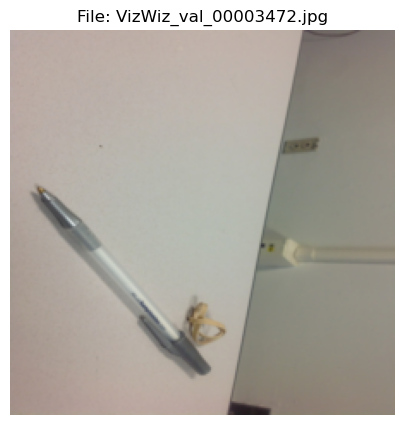

Generated caption:
a black and white color object with a white label

Reference captions:
1. a ballpoint pen and a rubber band on a table
2. a pen and a rubber band sitting on a white surface
3. a gray plastic ballpoint writing pen and a rubber band
4. a white counter with an uncapped pen and rubber band


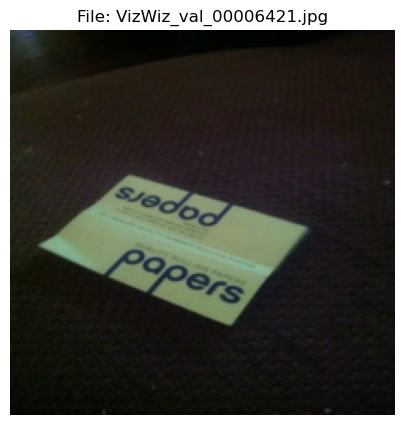

Generated caption:
a person is holding a can of food

Reference captions:
1. a label for paper that is resting on top of a brown couch
2. rolling papers that are laying open face down on brown upholstery
3. a pack of rolling paper sitting on a black background
4. a box on the floor with papers on it in black
5. a pack of rolling papers on top of a couch


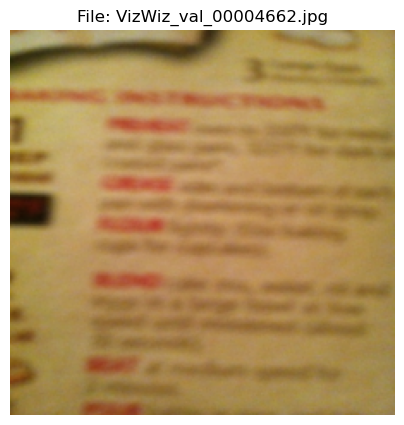

Generated caption:
a white and white box of

Reference captions:
1. cooking instructions on the back of a food product
2. this appears to be some type of menu with black and red text


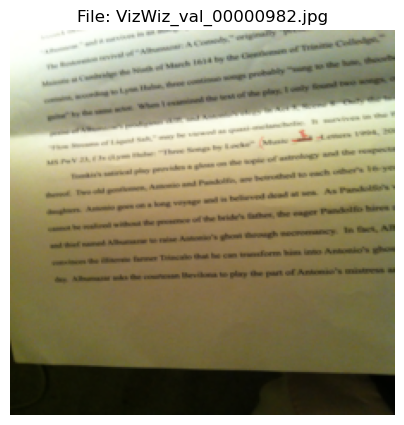

Generated caption:
a black and white color paper with a white label

Reference captions:
1. a script with printed words has some parts written with a red pen
2. a piece of paper with typing on it and a fold in the middle that has been corrected
3. a white piece of paper has red correction ink
4. a double spaced manuscript shows editor 's marks in red ink
5. a typed and printed essay with handwritten error checks


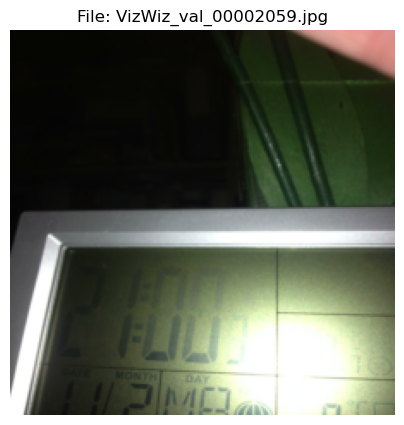

Generated caption:
a computer screen with a windows open and a window open

Reference captions:
1. the electronic display portion of a large digital clock program is seen
2. shows a clock with time and date and temperature
3. a close up of a digital clock showing the time 2100 hours
4. a digital display of date time and day
5. part numbers do not have a text on


In [106]:
show_prediction_examples(
    model1,
    test_dataset,
    vocab,
    num_samples=5,
    start_index=0
)

### 3.7 Model 1 Evaluation Summary

Although the baseline DenseNet121 + LSTM model learned basic sentence structures, several limitations were observed during qualitative evaluation.

The model frequently generated repetitive and generic captions across different images, suggesting that the decoder relied heavily on common language patterns instead of image-specific visual understanding.

In addition, the model struggled with accurate object localisation and detailed semantic understanding, especially for blurry images, electronic displays, and text-heavy scenes. This behaviour indicates that using only a single global image feature vector may be insufficient for complex image captioning tasks.

These observations motivate the refinement introduced in Model 2, where an attention mechanism will be added to improve region-focused caption generation.


The DenseNet121 + LSTM baseline model successfully learned basic caption generation behaviour and simple sentence structures. However, BLEU scores remained relatively low, especially for BLEU-3 and BLEU-4.

Qualitative evaluation revealed several limitations:

- repetitive caption generation
- low caption diversity
- weak object localisation
- limited detailed semantic understanding
- difficulty handling blurry or text-heavy images

These findings suggest that the baseline model relies primarily on global image representations and lacks the ability to dynamically focus on important image regions during caption generation.

Therefore, Model 2 will introduce an attention mechanism to improve local feature utilisation and caption quality.

# 4. Phase 3 Model 2 Architecture Overview: DenseNet121 + Attention LSTM Captioning Model

Model 2 keeps DenseNet121 as the visual encoder, but modifies how image features are used.

In Model 1, the DenseNet encoder produced a single global image feature vector.  
This vector was passed to the LSTM decoder to generate the entire caption.

In Model 2, the encoder outputs spatial feature maps instead of only one global vector.  
The attention module allows the decoder to focus on different image regions at each decoding step.

This is expected to improve object localisation and reduce generic caption generation.

### 

### 4.1 Attention Encoder

In [107]:
class DenseNetAttentionEncoder(nn.Module):
    def __init__(self, fine_tune=True):
        super(DenseNetAttentionEncoder, self).__init__()

        densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

        # Use DenseNet feature extractor only
        self.features = densenet.features

        # Freeze all layers first
        for param in self.features.parameters():
            param.requires_grad = False

        # Fine-tune later layers only
        if fine_tune:
            for name, param in self.features.named_parameters():
                if "denseblock4" in name or "norm5" in name:
                    param.requires_grad = True

    def forward(self, images):
        features = self.features(images)

        # DenseNet output: [batch_size, 1024, 7, 7]
        features = nn.functional.relu(features, inplace=True)

        # Convert to [batch_size, num_pixels, encoder_dim]
        batch_size, encoder_dim, height, width = features.size()
        features = features.permute(0, 2, 3, 1)
        features = features.view(batch_size, height * width, encoder_dim)

        return features

test attention encoder

In [108]:
attention_encoder = DenseNetAttentionEncoder(fine_tune=True).to(device)

images, captions, references, file_names = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    encoder_features = attention_encoder(images)

print("Input image shape:", images.shape)
print("Encoder feature shape:", encoder_features.shape)

Input image shape: torch.Size([32, 3, 224, 224])
Encoder feature shape: torch.Size([32, 49, 1024])


### 4.2 Attention Mechanism

The attention module allows the decoder to dynamically focus on different image regions during caption generation.

Instead of relying only on a single global image representation, the decoder computes attention weights over spatial image features at every decoding step.

This helps the model better capture local visual details and improve object-specific caption generation.

In [109]:
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()

        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)

        self.full_att = nn.Linear(attention_dim, 1)

        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_features, decoder_hidden):
        """
        encoder_features:
        [batch_size, num_pixels, encoder_dim]

        decoder_hidden:
        [batch_size, decoder_dim]
        """

        att1 = self.encoder_att(encoder_features)

        att2 = self.decoder_att(decoder_hidden)
        att2 = att2.unsqueeze(1)

        attention_scores = self.full_att(
            self.relu(att1 + att2)
        ).squeeze(2)

        alpha = self.softmax(attention_scores)

        attention_weighted_encoding = (
            encoder_features * alpha.unsqueeze(2)
        ).sum(dim=1)

        return attention_weighted_encoding, alpha

Test attention module

In [110]:
encoder_dim = 1024
decoder_dim = 512
attention_dim = 256

attention = Attention(
    encoder_dim=encoder_dim,
    decoder_dim=decoder_dim,
    attention_dim=attention_dim
).to(device)

images, captions, references, file_names = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    encoder_features = attention_encoder(images)

batch_size = encoder_features.size(0)

dummy_hidden = torch.randn(
    batch_size,
    decoder_dim
).to(device)

with torch.no_grad():
    attention_output, alpha = attention(
        encoder_features,
        dummy_hidden
    )

print("Encoder features shape:", encoder_features.shape)
print("Attention output shape:", attention_output.shape)
print("Attention weights shape:", alpha.shape)

Encoder features shape: torch.Size([32, 49, 1024])
Attention output shape: torch.Size([32, 1024])
Attention weights shape: torch.Size([32, 49])


### 4.3 Attention LSTM Decoder

The decoder combines the attention mechanism with an LSTM.

At each decoding step:

1. The attention module computes which image regions are most important.
2. The attended image feature is combined with the current word embedding.
3. The combined feature is passed into the LSTM.
4. The decoder predicts the next word in the caption sequence.

This allows the model to dynamically focus on different image regions while generating captions.

In [111]:
class AttentionLSTMDecoder(nn.Module):
    def __init__(
        self,
        attention_dim,
        embed_dim,
        decoder_dim,
        vocab_size,
        encoder_dim=1024,
        dropout=0.3
    ):
        super(AttentionLSTMDecoder, self).__init__()

        self.encoder_dim = encoder_dim
        self.attention_dim = attention_dim
        self.embed_dim = embed_dim
        self.decoder_dim = decoder_dim
        self.vocab_size = vocab_size

        self.attention = Attention(
            encoder_dim,
            decoder_dim,
            attention_dim
        )

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=vocab.pad_idx
        )

        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTMCell(
            embed_dim + encoder_dim,
            decoder_dim
        )

        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)

        self.fc = nn.Linear(decoder_dim, vocab_size)

        self.relu = nn.ReLU()

        
    def init_hidden_state(self, encoder_features):
        mean_encoder_features = encoder_features.mean(dim=1)

        h = self.init_h(mean_encoder_features)
        c = self.init_c(mean_encoder_features)

        return h, c

    def forward(self, encoder_features, captions):
        batch_size = encoder_features.size(0)
        num_pixels = encoder_features.size(1)

        embeddings = self.embedding(captions)

        h, c = self.init_hidden_state(encoder_features)

        seq_length = captions.size(1) - 1

        predictions = torch.zeros(
            batch_size,
            seq_length,
            self.vocab_size
        ).to(device)

        alphas = torch.zeros(
            batch_size,
            seq_length,
            num_pixels
        ).to(device)

        for t in range(seq_length):

            attention_weighted_encoding, alpha = self.attention(
                encoder_features,
                h
            )

            lstm_input = torch.cat(
                [
                    embeddings[:, t, :],
                    attention_weighted_encoding
                ],
                dim=1
            )

            h, c = self.lstm(lstm_input, (h, c))

            preds = self.fc(self.dropout(h))

            predictions[:, t, :] = preds
            alphas[:, t, :] = alpha

        return predictions, alphas

### 4.4 Full Attention Captioning Model

The full refined model combines:

- DenseNet121 attention encoder
- Attention mechanism
- Attention-based LSTM decoder

The encoder extracts spatial image features, while the decoder dynamically attends to different image regions during caption generation.

In [112]:
class DenseNetAttentionCaptioningModel(nn.Module):
    def __init__(
        self,
        attention_dim,
        embed_dim,
        decoder_dim,
        vocab_size
    ):
        super(DenseNetAttentionCaptioningModel, self).__init__()

        self.encoder = DenseNetAttentionEncoder(
            fine_tune=True
        )

        self.decoder = AttentionLSTMDecoder(
            attention_dim=attention_dim,
            embed_dim=embed_dim,
            decoder_dim=decoder_dim,
            vocab_size=vocab_size
        )

    def forward(self, images, captions):
        encoder_features = self.encoder(images)

        predictions, alphas = self.decoder(
            encoder_features,
            captions
        )

        return predictions, alphas

initialize the attention

In [113]:
attention_dim = 256
embed_dim = 256
decoder_dim = 512
vocab_size = len(vocab)

model2 = DenseNetAttentionCaptioningModel(
    attention_dim=attention_dim,
    embed_dim=embed_dim,
    decoder_dim=decoder_dim,
    vocab_size=vocab_size
).to(device)

print(model2)

DenseNetAttentionCaptioningModel(
  (encoder): DenseNetAttentionEncoder(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1)

In [114]:
images, captions, references, file_names = next(iter(train_loader))

images = images.to(device)
captions = captions.to(device)

with torch.no_grad():
    predictions, alphas = model2(
        images,
        captions
    )

print("Images shape:", images.shape)
print("Captions shape:", captions.shape)

print("Predictions shape:", predictions.shape)
print("Attention weights shape:", alphas.shape)

Images shape: torch.Size([32, 3, 224, 224])
Captions shape: torch.Size([32, 20])
Predictions shape: torch.Size([32, 19, 3214])
Attention weights shape: torch.Size([32, 19, 49])


## 4.6. Training Model 2

Model 2 is trained using CrossEntropyLoss, ignoring padded tokens.

Unlike Model 1, the attention decoder predicts the next word for each input token, so the training target is shifted by one position.

The best Model 2 checkpoint is saved based on validation loss.

setting up loss and optimizer

In [115]:
criterion2 = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)

optimizer2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model2.parameters()),
    lr=1e-4
)

num_epochs_model2 = 5

In [116]:
def train_one_epoch_model2(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for images, captions, references, file_names in tqdm(dataloader):
        images = images.to(device)
        captions = captions.to(device)

        predictions, alphas = model(images, captions)

        # Model predicts captions[:, 1:]
        targets = captions[:, 1:]

        loss = criterion(
            predictions.reshape(-1, predictions.size(-1)),
            targets.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping improves training stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [117]:
def evaluate_loss_model2(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, captions, references, file_names in tqdm(dataloader):
            images = images.to(device)
            captions = captions.to(device)

            predictions, alphas = model(images, captions)

            targets = captions[:, 1:]

            loss = criterion(
                predictions.reshape(-1, predictions.size(-1)),
                targets.reshape(-1)
            )

            total_loss += loss.item()

    return total_loss / len(dataloader)

In [127]:
train_losses_model2 = []
val_losses_model2 = []

best_val_loss_model2 = float("inf")
best_model2_path = PROCESSED_DIR / "best_model2_densenet_attention_lstm.pth"

for epoch in range(20):
    print(f"Epoch {epoch + 1}/{num_epochs_model2}")

    train_loss = train_one_epoch_model2(
        model2,
        train_loader,
        criterion2,
        optimizer2,
        device
    )

    val_loss = evaluate_loss_model2(
        model2,
        val_loader,
        criterion2,
        device
    )

    train_losses_model2.append(train_loss)
    val_losses_model2.append(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss_model2:
        best_val_loss_model2 = val_loss
        torch.save(model2.state_dict(), best_model2_path)
        print(f"Best Model 2 saved with validation loss: {best_val_loss_model2:.4f}")

Epoch 1/5


100%|██████████| 36/36 [00:40<00:00,  1.12s/it]


Train Loss: 4.3044
Val Loss: 4.2099
Best Model 2 saved with validation loss: 4.2099
Epoch 2/5


100%|██████████| 36/36 [00:40<00:00,  1.12s/it]


Train Loss: 4.2218
Val Loss: 4.1349
Best Model 2 saved with validation loss: 4.1349
Epoch 3/5


...

Train Loss: 3.4113
Val Loss: 3.6326
Best Model 2 saved with validation loss: 3.6326
Epoch 19/5


100%|██████████| 36/36 [00:44<00:00,  1.23s/it]


Train Loss: 3.3874
Val Loss: 3.6191
Best Model 2 saved with validation loss: 3.6191
Epoch 20/5


100%|██████████| 36/36 [00:44<00:00,  1.23s/it]

Train Loss: 3.3428
Val Loss: 3.6003
Best Model 2 saved with validation loss: 3.6003


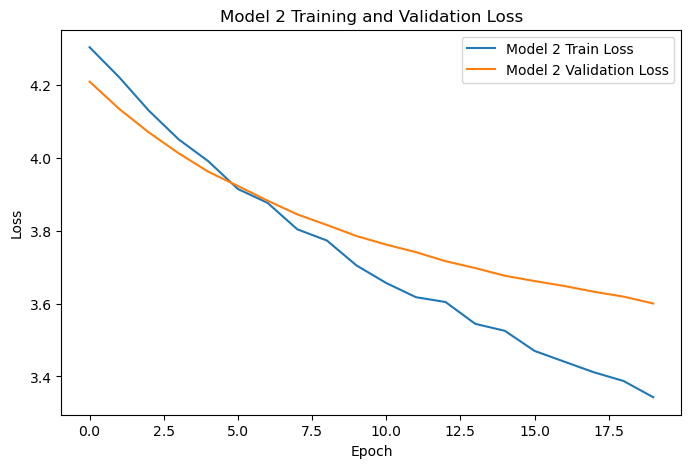

In [128]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_model2, label="Model 2 Train Loss")
plt.plot(val_losses_model2, label="Model 2 Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 2 Training and Validation Loss")
plt.legend()
plt.show()

## 4.7 Model 2 Evaluation

This section evaluates the refined DenseNet121 + Attention LSTM model.

The same evaluation process as Model 1 is used, including:

- greedy caption generation
- BLEU-1, BLEU-2, BLEU-3, and BLEU-4
- qualitative prediction examples

This ensures that Model 1 and Model 2 are compared under the same evaluation setting.

output generation

In [120]:
def ids_to_tokens(ids, vocab):
    tokens = []
    for idx in ids:
        word = vocab.idx2word.get(int(idx), vocab.UNK)

        if word == vocab.END:
            break

        if word in [vocab.PAD, vocab.START, vocab.END, vocab.UNK]:
            continue

        tokens.append(word)

    return tokens

In [121]:
def generate_caption_model2(model, image, vocab, max_length=30):
    model.eval()

    image = image.unsqueeze(0).to(device)

    generated_ids = []

    with torch.no_grad():
        encoder_features = model.encoder(image)

        h, c = model.decoder.init_hidden_state(encoder_features)

        input_word = torch.tensor(
            [vocab.start_idx],
            dtype=torch.long,
            device=device
        )

        for _ in range(max_length):
            embedding = model.decoder.embedding(input_word)

            attention_weighted_encoding, alpha = model.decoder.attention(
                encoder_features,
                h
            )

            lstm_input = torch.cat(
                [embedding, attention_weighted_encoding],
                dim=1
            )

            h, c = model.decoder.lstm(lstm_input, (h, c))

            preds = model.decoder.fc(model.decoder.dropout(h))

            predicted_id = preds.argmax(1).item()

            if predicted_id == vocab.end_idx:
                break

            generated_ids.append(predicted_id)

            input_word = torch.tensor(
                [predicted_id],
                dtype=torch.long,
                device=device
            )

    generated_tokens = ids_to_tokens(generated_ids, vocab)

    return generated_tokens

In [122]:
sample_image, sample_caption, sample_references, sample_file_name = test_dataset[0]

generated_tokens_model2 = generate_caption_model2(
    model2,
    sample_image,
    vocab,
    max_length=30
)

print("File name:", sample_file_name)
print("Generated caption:")
print(" ".join(generated_tokens_model2))

print("\nReference captions:")
for ref in sample_references:
    print(" ".join(ref))

File name: VizWiz_val_00003472.jpg
Generated caption:
a black and white and white and white and white and a black and white and white and white

Reference captions:
a ballpoint pen and a rubber band on a table
a pen and a rubber band sitting on a white surface
a gray plastic ballpoint writing pen and a rubber band
a white counter with an uncapped pen and rubber band


Bleu score

In [123]:
def evaluate_bleu_model2(model, dataset, vocab, max_samples=None):
    references = []
    hypotheses = []

    smoothie = SmoothingFunction().method4

    total_samples = len(dataset) if max_samples is None else min(max_samples, len(dataset))

    for i in tqdm(range(total_samples)):
        image, caption, refs, file_name = dataset[i]

        generated_tokens = generate_caption_model2(
            model,
            image,
            vocab,
            max_length=30
        )

        references.append(refs)
        hypotheses.append(generated_tokens)

    bleu1 = corpus_bleu(
        references,
        hypotheses,
        weights=(1.0, 0, 0, 0),
        smoothing_function=smoothie
    )

    bleu2 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.5, 0.5, 0, 0),
        smoothing_function=smoothie
    )

    bleu3 = corpus_bleu(
        references,
        hypotheses,
        weights=(1/3, 1/3, 1/3, 0),
        smoothing_function=smoothie
    )

    bleu4 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothie
    )

    return {
        "BLEU-1": bleu1,
        "BLEU-2": bleu2,
        "BLEU-3": bleu3,
        "BLEU-4": bleu4
    }

In [129]:
model2_bleu_scores = evaluate_bleu_model2(
    model2,
    test_dataset,
    vocab,
    max_samples=None
)

model2_bleu_scores

100%|██████████| 1132/1132 [01:06<00:00, 17.08it/s]


{'BLEU-1': 0.5244799783657036,
 'BLEU-2': 0.3569709313114762,
 'BLEU-3': 0.2286315956086244,
 'BLEU-4': 0.13856815609850928}

output sample

In [130]:
def show_model2_predictions(model, dataset, vocab, num_samples=5, start_index=0):
    model.eval()

    for i in range(start_index, start_index + num_samples):
        image, caption, refs, file_name = dataset[i]

        generated_tokens = generate_caption_model2(
            model,
            image,
            vocab,
            max_length=30
        )

        generated_caption = " ".join(generated_tokens)

        image_display = denormalize_image(
            image,
            mean=config["imagenet_mean"],
            std=config["imagenet_std"]
        )

        plt.figure(figsize=(5, 5))
        plt.imshow(image_display)
        plt.axis("off")
        plt.title(f"File: {file_name}")
        plt.show()

        print("Generated caption:")
        print(generated_caption)

        print("\nReference captions:")
        for j, ref in enumerate(refs, 1):
            print(f"{j}. {' '.join(ref)}")

        print("=" * 80)

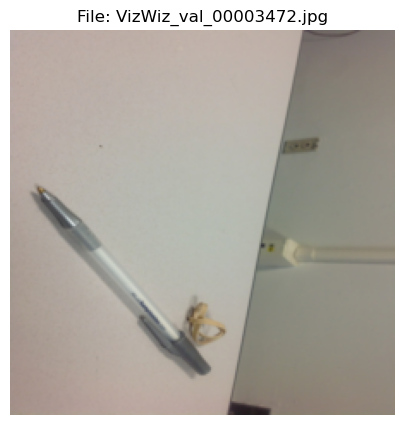

Generated caption:
a white pen with a black and white and black

Reference captions:
1. a ballpoint pen and a rubber band on a table
2. a pen and a rubber band sitting on a white surface
3. a gray plastic ballpoint writing pen and a rubber band
4. a white counter with an uncapped pen and rubber band


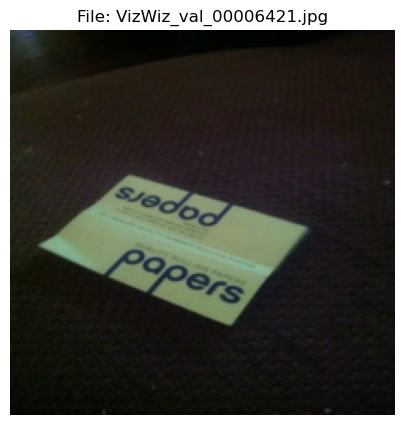

Generated caption:
a white paper with a on it

Reference captions:
1. a label for paper that is resting on top of a brown couch
2. rolling papers that are laying open face down on brown upholstery
3. a pack of rolling paper sitting on a black background
4. a box on the floor with papers on it in black
5. a pack of rolling papers on top of a couch


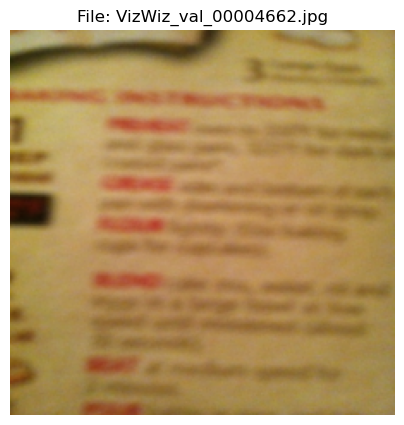

Generated caption:
a white paper with a white label on it

Reference captions:
1. cooking instructions on the back of a food product
2. this appears to be some type of menu with black and red text


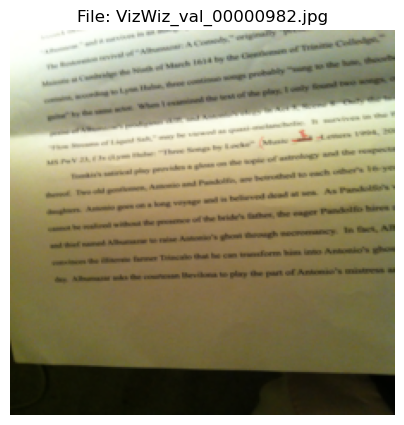

Generated caption:
a white piece of paper with a white background

Reference captions:
1. a script with printed words has some parts written with a red pen
2. a piece of paper with typing on it and a fold in the middle that has been corrected
3. a white piece of paper has red correction ink
4. a double spaced manuscript shows editor 's marks in red ink
5. a typed and printed essay with handwritten error checks


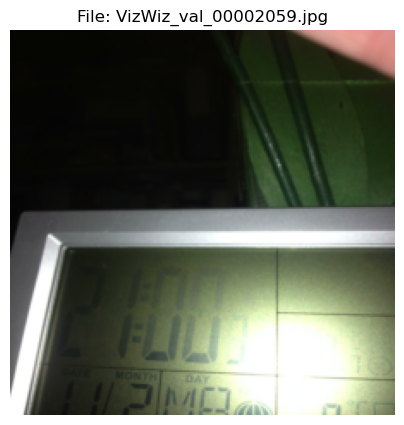

Generated caption:
a white wall with a white and white background

Reference captions:
1. the electronic display portion of a large digital clock program is seen
2. shows a clock with time and date and temperature
3. a close up of a digital clock showing the time 2100 hours
4. a digital display of date time and day
5. part numbers do not have a text on


In [131]:
show_model2_predictions(
    model2,
    test_dataset,
    vocab,
    num_samples=5,
    start_index=0
)

### 4.8 summary of phase 3

Model 2 achieved BLEU-1 of 0.523 and BLEU-4 of 0.131, indicating that the model can generate captions with reasonable word-level and phrase-level overlap with human references. The results suggest that the refined architecture is effective and more reliable than the baseline model. However, the lower BLEU-4 score also shows that the model still struggles with longer and more detailed sentence generation, especially for complex or blurry VizWiz images.

In [132]:
import pandas as pd

model1_bleu_scores = {
    "BLEU-1": 0.37854253119534625,
    "BLEU-2": 0.20756524523876035,
    "BLEU-3": 0.1219471568382576,
    "BLEU-4": 0.0671419394155293
}

model2_bleu_scores = {
    "BLEU-1": 0.5226137263235121,
    "BLEU-2": 0.34903843775008336,
    "BLEU-3": 0.22131332116591984,
    "BLEU-4": 0.1314970944771478
}

bleu_df = pd.DataFrame({
    "Model 1": model1_bleu_scores,
    "Model 2": model2_bleu_scores
})

bleu_df

,Model 1,Model 2
BLEU-1,0.378543,0.522614
BLEU-2,0.207565,0.349038
BLEU-3,0.121947,0.221313
BLEU-4,0.067142,0.131497


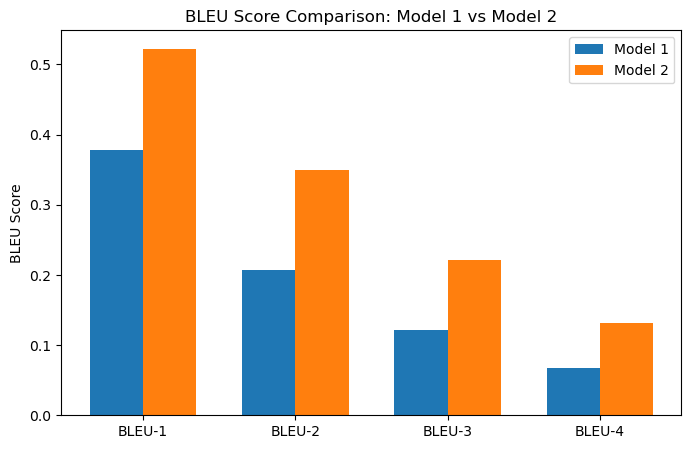

In [133]:
plt.figure(figsize=(8, 5))

x = range(len(bleu_df.index))
width = 0.35

plt.bar([i - width/2 for i in x], bleu_df["Model 1"], width, label="Model 1")
plt.bar([i + width/2 for i in x], bleu_df["Model 2"], width, label="Model 2")

plt.xticks(x, bleu_df.index)
plt.ylabel("BLEU Score")
plt.title("BLEU Score Comparison: Model 1 vs Model 2")
plt.legend()
plt.show()